Análisis Exploratorio de Datos (EDA)

En este notebook revisamos la calidad del dataset histórico de clientes, si hay datos faltantes o duplicados, y analizamos cómo se comportan las variables más importantes antes de armar los modelos de predicción.

In [1]:
# Importo pandas y librerías para hacer visualizaciones
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargo el dataset histórico de clientes
df = pd.read_csv("../data/raw/customer_churn_historical.csv")

#Muestro las 5 primeras filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6684-LWVH,Male,0,No,No,4,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,27.56,107.47,No
1,7027-JIFO,Male,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,30.52,1020.47,No
2,5981-VOQO,Female,0,No,No,45,Yes,Yes,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),66.87,2686.35,No
3,7266-HYDM,Male,0,Yes,No,31,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),86.95,2536.96,Yes
4,2821-JDLS,Female,0,Yes,No,5,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,30.18,139.12,No


In [2]:
# Para ver la cantidad de columnas y filas del dataset
df.shape

(7043, 21)

In [3]:
# Para que muestre cuáles son las columnas y qué tipos de datos tienen
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Para obtener estadísticas descriptivas de las vairables numéricas
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7017.000000
mean,0.170098,35.168394,68.168503,2312.077586
std,0.375746,18.901478,24.980659,1573.967858
min,0.000000,0.000000,18.000000,0.000000
25%,0.000000,20.000000,55.360000,986.630000
50%,0.000000,35.000000,73.910000,2013.200000
75%,0.000000,51.000000,88.000000,3452.850000
max,1.000000,72.000000,114.410000,7761.340000


In [5]:
# Para ver la cantidad de valores faltantes en cada columna
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        26
Churn                0
dtype: int64

In [6]:
# Para comprobar si existen filas duplicadas
df.duplicated().sum()

np.int64(0)

In [7]:
# Para contar la cantidad de clientes en cada categoría de "Churn" (clientes que abandonaron la empresa)
df["Churn"].value_counts()

Churn
No     5186
Yes    1857
Name: count, dtype: int64

"Yes" son los clientes que abandonaron la empresa.

In [8]:
# Lo transformo en un porcentaje
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.633395
Yes    26.366605
Name: proportion, dtype: float64

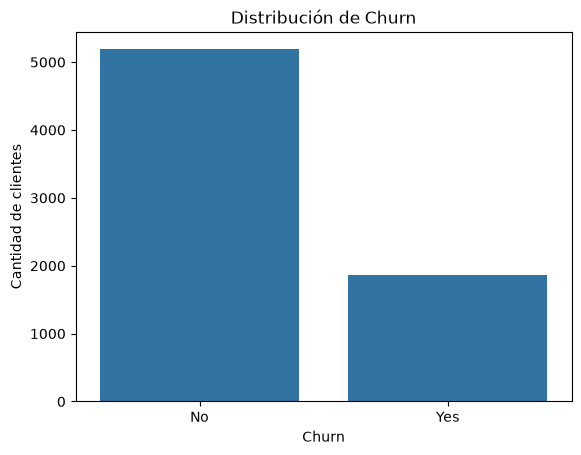

In [9]:
# Para visualizar la distribución de la variable objetivo
sns.countplot(data=df, x="Churn")

plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()

Distribución de Churn:

Casi un 74% de los clientes se queda en la compañía y un 26% se va. Como las dos clases no están en partes iguales, guiarnos solo por el Accuracy va a ser engañoso, un modelo que diga siempre que nadie se va, tendría un 74% de aciertos, sin servir de nada para el negocio.

In [10]:
# Para ver la cantidad de clientes en cada categoría de "SeniorCitizen" 
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5845
1    1198
Name: count, dtype: int64

SeniorCitizen indica si el cliente es un adulto mayor.
Según la documentación del dataset, 0 indica que el cliente no es un adulto mayor, y el valor 1 indica que sí lo es.

In [11]:
# Para ver las categorías de algunas columnas
print("gender:")
print(df["gender"].unique())

print("\nContract:")
print(df["Contract"].unique())

print("\nInternetService:")
print(df["InternetService"].unique())

print("\nPaymentMethod:")
print(df["PaymentMethod"].unique())

gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Contract:
<StringArray>
['One year', 'Month-to-month', 'Two year']
Length: 3, dtype: str

InternetService:
<StringArray>
['No', 'DSL', 'Fiber optic']
Length: 3, dtype: str

PaymentMethod:
<StringArray>
[             'Mailed check', 'Bank transfer (automatic)',
          'Electronic check',   'Credit card (automatic)']
Length: 4, dtype: str


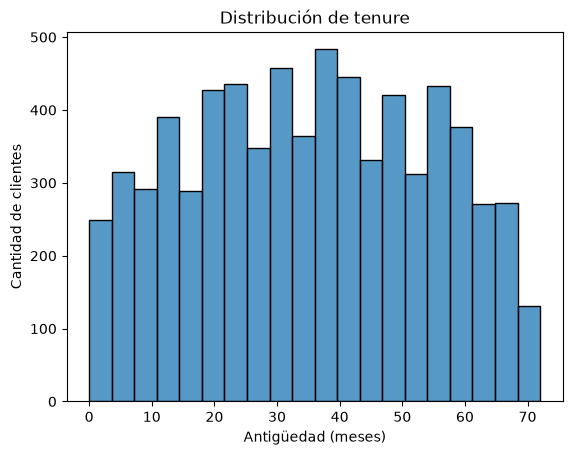

In [12]:
# Distribución de la antigüedad (tenure) de los clientes
sns.histplot(data=df, x="tenure", bins=20)

plt.title("Distribución de tenure")
plt.xlabel("Antigüedad (meses)")
plt.ylabel("Cantidad de clientes")
plt.show()

Tipo de contrato vs churn:

In [13]:
# Para analizar la distribución de Churn según el tipo de contrato (en porcentaje)
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,61.270008,38.729992
One year,85.026385,14.973615
Two year,91.025641,8.974359


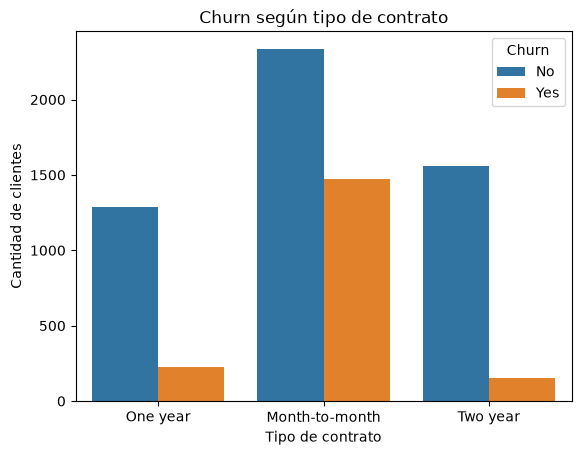

In [14]:
# Para visualizar la relación entre tipo de contrato y Churn
sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.show()

Los clientes con contrato mensual (Month-to-month) son, con diferencia, los que más abandonan la empresa. El tipo de contrato es un factor clave para anticipar la fuga.

Antigüedad vs churn:

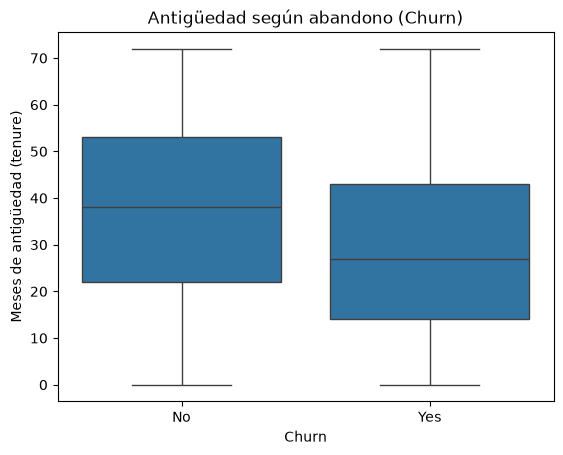

In [15]:
# Relación directa entre antigüedad y abandono
sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Antigüedad según abandono (Churn)")
plt.xlabel("Churn")
plt.ylabel("Meses de antigüedad (tenure)")
plt.show()

In [16]:
# Para crear grupos de antigüedad y así poder analizar mejor
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 36, 48, 60, 72],
    labels=["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
)

In [17]:
# Para analizar la distribución de Churn según grupos de antigüedad
pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100

Churn,No,Yes
tenure_group,,
0-12,60.212972,39.787028
13-24,66.243050,33.756950
25-36,73.733719,26.266281
37-48,76.547706,23.452294
49-60,81.239804,18.760196
61-72,86.233766,13.766234


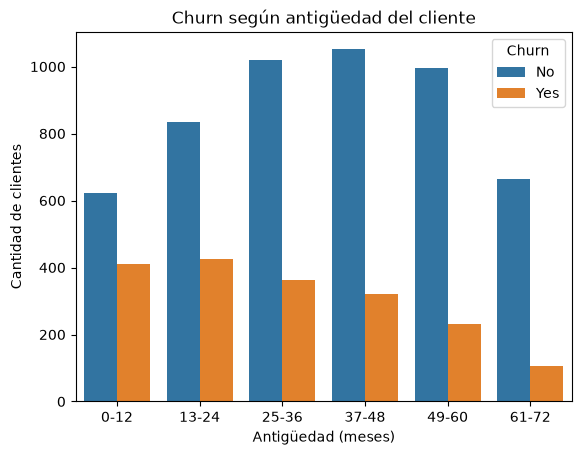

In [18]:
# Para visualizar Churn según los grupos de antigüedad recién creados.
sns.countplot(data=df, x="tenure_group", hue="Churn")

plt.title("Churn según antigüedad del cliente")
plt.xlabel("Antigüedad (meses)")
plt.ylabel("Cantidad de clientes")
plt.show()

Relación entre antigüedad y Churn

Podemos observar que el porcentaje de clientes que abandona la empresa disminuye a medida que aumenta su antigüedad.
En el grupo de 0 a 12 meses el porcentaje de Churn es cercano al 40 %, mientras que en el grupo de 61 a 72 meses de antigüedad es considerablemente menor. 

Charges vs churn

In [19]:
# Para comparar los cargos mensuales según Churn
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5186.0,63.940046,25.666951,18.0,33.84,69.305,84.86,114.41
Yes,1857.0,79.977216,18.378920,18.0,71.73,84.690,92.14,114.16


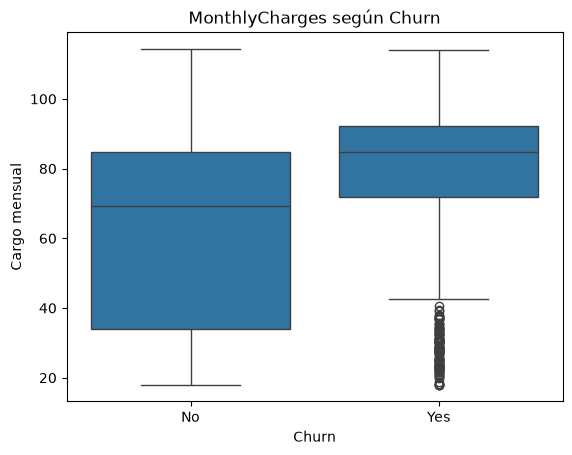

In [20]:
# Para visualizar la distribución de los cargos mensuales según Churn
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("MonthlyCharges según Churn")
plt.xlabel("Churn")
plt.ylabel("Cargo mensual")
plt.show()

In [21]:
# Para comparar los cargos totales según Churn
df.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5168.0,2324.697043,1590.017557,0.0,985.6425,1986.725,3493.7625,7761.34
Yes,1849.0,2276.805895,1528.084349,0.0,994.9100,2084.560,3343.8100,7314.48


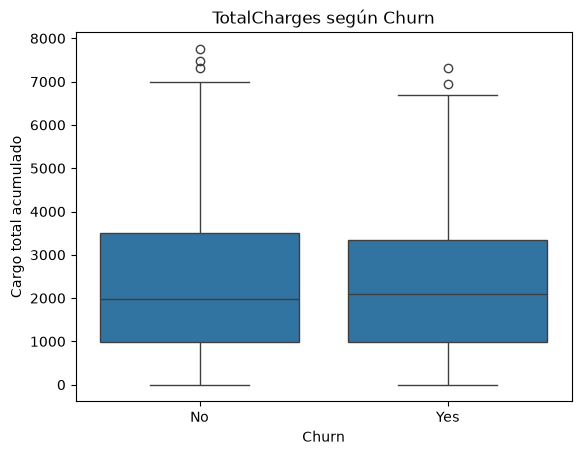

In [22]:
# Para visualizar la distribución de los cargos totales según Churn
sns.boxplot(data=df, x="Churn", y="TotalCharges")

plt.title("TotalCharges según Churn")
plt.xlabel("Churn")
plt.ylabel("Cargo total acumulado")
plt.show()

Cargos mensuales (MonthlyCharges): Los clientes que se van, suelen pagar cuotas mensuales más caras, la mayoría supera los 80 dólares por mes.
Cargos acumulados (TotalCharges): Ambas distribuciones son casi iguales (las medianas son de casi 2000 dólares). Esta variable por sí sola no sirve para distinguir si un cliente se va o se queda.

In [23]:
# Para inspeccionar las filas con nulos en TotalCharges
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
95,0,24.03,NaN
781,0,83.01,NaN
854,0,68.81,NaN
867,0,75.01,NaN
882,0,74.50,NaN
1013,0,24.19,NaN
1172,0,89.15,NaN
1842,0,89.85,NaN
2112,0,59.50,NaN
2346,0,84.69,NaN


Valores faltantes en TotalCharges:

Los 26 nulos en TotalCharges son clientes que recién entran a la empresa (tenure == 0), y como todavía no cumplieron ni su primer mes, la empresa todavía no les cobró nada acumulado.
Por eso, más adelante lo correcto va a ser llenar esos vacíos con el número 0.

In [24]:
# Para ver cómo se relacionan entre sí los números
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.000735,0.785992
MonthlyCharges,0.000735,1.000000,0.543910
TotalCharges,0.785992,0.543910,1.000000


Relación entre variables numéricas:

La antigüedad y el gasto total van muy de la mano (0.786): el gasto total prácticamente repite lo que ya nos dice el tiempo que lleva el cliente.
La cuota mensual no tiene ninguna relación con el tiempo que lleva el cliente (0.0007): la empresa cobra lo mismo sin importar la antigüedad.

In [25]:
# Para borrar la columna auxiliar y comprobar que haya sido borrada
df = df.drop(columns=["tenure_group"])
print("Dimensiones finales:", df.shape)

Dimensiones finales: (7043, 21)
